In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

RANDOM_STATE = 42

# 项目路径配置
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "分析代码":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DATA_DIR = PROJECT_ROOT / "数据" / "原始数据"
PROCESSED_DATA_DIR = PROJECT_ROOT / "数据" / "处理后数据"

assert RAW_DATA_DIR.exists(), f"找不到原始数据目录：{RAW_DATA_DIR}"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"项目目录配置完成")


项目目录配置完成


In [2]:
# 一、数据处理
# 1. 显示全部列

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# 2. 读取数据

df = pd.read_csv(RAW_DATA_DIR / "Project Dataset.csv")
print("数据加载成功！")

# 3. 数据基础信息

print("\n【前5行】")
print(df.head())


数据加载成功！

【前5行】
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome MaritalStatus  AgeGroup  Gender  HourSpendOnApp  OrderCount  OrderAmountHikeFromlastYear  DaySinceLastOrder  \
0       50001      1     4.0         Mobile Phone         3              6.0        Single         3  Female             3.0         1.0                         11.0                5.0   
1       50002      1     NaN                Phone         1              8.0        Single         4    Male             3.0         1.0                         15.0                0.0   
2       50003      1     NaN                Phone         1             30.0        Single         4    Male             2.0         1.0                         14.0                3.0   
3       50004      1     3.0                Phone         3             15.0        Single         4    Male             2.0         1.0                         23.0                3.0   
4       50005      1     3.0                P

In [3]:
# 4. 清洗前数据审计
df_raw = df.copy()

missing_summary = (pd.DataFrame({'DataType': df.dtypes.astype(str),
                                 'MissingCount': df.isna().sum(),
                                 'MissingRate': df.isna().mean(),
                                 'UniqueCount': df.nunique(dropna=False)}).sort_values('MissingRate', ascending=False))

print(f'原始数据：{df.shape[0]:,}行，{df.shape[1]}列')
print(f'整行重复：{df.duplicated().sum():,}行')
print(f'CustomerID重复：{df["CustomerID"].duplicated().sum():,}行')

display(missing_summary)

原始数据：5,630行，19列
整行重复：0行
CustomerID重复：0行


,DataType,MissingCount,MissingRate,UniqueCount
DaySinceLastOrder,float64,307,0.054529,23
OrderAmountHikeFromlastYear,float64,265,0.047069,17
Tenure,float64,264,0.046892,34
OrderCount,float64,258,0.045826,17
CouponUsed,float64,256,0.045471,18
HourSpendOnApp,float64,255,0.045293,7
WarehouseToHome,float64,251,0.044583,35
Complain,int64,0,0.000000,2
SatisfactionScore,int64,0,0.000000,5
NumberOfStreamerFollowed,int64,0,0.000000,15


In [4]:
# 5. 处理缺失值

# 保留原始数据，方便核对清洗前后差异
df_raw = df.copy()

# 文本标准化
df['PreferredLoginDevice'] = (df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'}).astype('string'))

# 连续变量：中位数填充
continuous_impute_cols = ['Tenure','WarehouseToHome','HourSpendOnApp',
                          'OrderAmountHikeFromlastYear','DaySinceLastOrder']

# 离散计数变量：中位数填充后取整
count_impute_cols = ['OrderCount', 'CouponUsed']

imputation_records = []

for col in continuous_impute_cols:
    missing_count = df[col].isna().sum()
    fill_value = df[col].median()

    df[col] = df[col].fillna(fill_value)

    imputation_records.append({'Feature': col,
                               'MissingCount': missing_count,
                               'MissingRate': missing_count / len(df_raw),
                               'ImputationMethod': 'Median',
                               'FillValue': fill_value})

for col in count_impute_cols:
    missing_count = df[col].isna().sum()
    fill_value = round(df[col].median())

    df[col] = df[col].fillna(fill_value).round().astype(int)

    imputation_records.append({'Feature': col,
                               'MissingCount': missing_count,
                               'MissingRate': missing_count / len(df_raw),
                               'ImputationMethod': 'Rounded median',
                               'FillValue': fill_value})

imputation_summary = pd.DataFrame(imputation_records)

print("清洗前行数：", len(df_raw))
print("清洗后行数：", len(df))
print("剩余缺失值：", df.isna().sum().sum())
display(imputation_summary)


清洗前行数： 5630
清洗后行数： 5630
剩余缺失值： 0


,Feature,MissingCount,MissingRate,ImputationMethod,FillValue
0,Tenure,264,0.046892,Median,9.0
1,WarehouseToHome,251,0.044583,Median,14.0
2,HourSpendOnApp,255,0.045293,Median,3.0
3,OrderAmountHikeFromlastYear,265,0.047069,Median,15.0
4,DaySinceLastOrder,307,0.054529,Median,3.0
5,OrderCount,258,0.045826,Rounded median,2.0
6,CouponUsed,256,0.045471,Rounded median,1.0


In [5]:
# 6. 清洗后数据与原数据比对

quality_audit = pd.DataFrame({'Metric': ['Raw rows',
                                         'Clean rows',
                                         'Removed rows',
                                         'Removed rate',
                                         'Raw churn rate',
                                         'Clean churn rate',
                                         'Duplicate CustomerID'],
                              'Value': [len(df_raw),
                                        len(df),
                                        len(df_raw) - len(df),
                                        (len(df_raw) - len(df)) / len(df_raw),
                                        df_raw['Churn'].mean(),
                                        df['Churn'].mean(),
                                        df['CustomerID'].duplicated().sum()]})

display(quality_audit)



,Metric,Value
0,Raw rows,5630.000000
1,Clean rows,5630.000000
2,Removed rows,0.000000
3,Removed rate,0.000000
4,Raw churn rate,0.168384
5,Clean churn rate,0.168384
6,Duplicate CustomerID,0.000000


In [6]:
# 7. 数值字段描述统计

print("\n【数值字段统计】")

desc = df.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T

desc = desc[['count','mean','std',
             'min','1%','5%','25%',
             '50%','75%','95%',
             '99%','max']]

print(desc)



【数值字段统计】
                              count          mean          std      min        1%        5%       25%      50%       75%       95%       99%      max
CustomerID                   5630.0  52815.500000  1625.385339  50001.0  50057.29  50282.45  51408.25  52815.5  54222.75  55348.55  55573.71  55630.0
Churn                        5630.0      0.168384     0.374240      0.0      0.00      0.00      0.00      0.0      0.00      1.00      1.00      1.0
Tenure                       5630.0     10.612611     8.257343      1.0      1.00      1.00      3.00      9.0     15.00     27.00     33.00     63.0
CityTier                     5630.0      1.654707     0.915389      1.0      1.00      1.00      1.00      1.0      3.00      3.00      3.00      3.0
WarehouseToHome              5630.0     15.566785     8.345961      5.0      6.00      6.00      9.00     14.0     20.00     32.00     35.00    127.0
AgeGroup                     5630.0      3.688988     1.023999      1.0      1.00      2.0

In [7]:
# 8. 业务规则检查
non_negative_cols = ['Tenure','WarehouseToHome','HourSpendOnApp','OrderCount','OrderAmountHikeFromlastYear',
                     'DaySinceLastOrder','NumberOfStreamerFollowed','CouponUsed','DiscountAmount']

#  检查数值列是否存在负值
business_check = pd.DataFrame({'Feature': non_negative_cols,
                               'NegativeCount': [(df[col] < 0).sum()
                                                 for col in non_negative_cols],
                                'Min': [df[col].min()
                                        for col in non_negative_cols],
                                'Max': [df[col].max()
                                        for col in non_negative_cols]})

display(business_check)


valid_values = {'Churn': {0, 1},
                'Complain': {0, 1},
                'CityTier': {1, 2, 3},
                'SatisfactionScore': {1, 2, 3, 4, 5}}

for col, expected in valid_values.items():
    actual = set(df[col].dropna().unique())
    unexpected = actual - expected
    print(f'{col}异常取值：{unexpected}')

,Feature,NegativeCount,Min,Max
0,Tenure,0,1.0,63.0
1,WarehouseToHome,0,5.0,127.0
2,HourSpendOnApp,0,0.0,5.0
3,OrderCount,0,1.0,16.0
4,OrderAmountHikeFromlastYear,0,11.0,26.0
5,DaySinceLastOrder,0,0.0,46.0
6,NumberOfStreamerFollowed,0,1.0,22.0
7,CouponUsed,0,0.0,16.0
8,DiscountAmount,0,0.0,325.0


Churn异常取值：set()
Complain异常取值：set()
CityTier异常取值：set()
SatisfactionScore异常取值：set()


In [8]:
# 9. 异常值检查

outlier_check_cols = ['Tenure','WarehouseToHome','HourSpendOnApp','OrderCount','OrderAmountHikeFromlastYear',
                      'DaySinceLastOrder','NumberOfStreamerFollowed','CouponUsed','DiscountAmount']

outlier_records = []

for col in outlier_check_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_records.append({'Feature': col,
                            'Min': df[col].min(),
                            'Max': df[col].max(),
                            'IQRLower': lower,
                            'IQRUpper': upper,
                            'PotentialOutliers': ((df[col] < lower) | (df[col] > upper)).sum()})

outlier_summary = pd.DataFrame(outlier_records)
display(outlier_summary)

,Feature,Min,Max,IQRLower,IQRUpper,PotentialOutliers
0,Tenure,1.0,63.0,-15.0,33.0,4
1,WarehouseToHome,5.0,127.0,-7.5,36.5,2
2,HourSpendOnApp,0.0,5.0,0.5,4.5,6
3,OrderCount,1.0,16.0,-2.0,6.0,703
4,OrderAmountHikeFromlastYear,11.0,26.0,5.5,25.5,33
5,DaySinceLastOrder,0.0,46.0,-5.5,14.5,62
6,NumberOfStreamerFollowed,1.0,22.0,-4.0,12.0,4
7,CouponUsed,0.0,16.0,-0.5,3.5,629
8,DiscountAmount,0.0,325.0,71.0,271.0,447


IQR仅用于识别潜在异常值。经业务范围检查后，相关高值仍处于合理范围，因此予以保留，不根据流失标签删除或修改异常值。

In [9]:
# 二、特征工程，衍生字段

# 1. 是否使用优惠券
df['CouponFlag'] = np.where(df['CouponUsed']>0,'Used','Not Used')

print(df['CouponFlag'].value_counts())

# 2. 用户生命周期（月）
df['TenureGroup'] = pd.cut(df['Tenure'],
                           bins=[-np.inf,6,12,24,np.inf],
                           labels=['0-6M','6-12M','1-2Y','2Y+'])

print(df['TenureGroup'].value_counts())

# 3. APP使用程度
df['AppUsageLevel'] = pd.cut(df['HourSpendOnApp'],
                             bins=[-np.inf,1,2,3,np.inf],
                             labels=['Low','Medium','High','Very High'])

print(df['AppUsageLevel'].value_counts())

# 4. 主播关注分组
df['StreamerGroup'] = pd.cut(df['NumberOfStreamerFollowed'],
                             bins=[-np.inf,3,6,np.inf],
                             labels=['0-3','4-6','7+'])

print(df['StreamerGroup'].value_counts())

# 5. 最近下单天数分组
df['LastOrderGroup']=pd.cut(df['DaySinceLastOrder'],
                            bins=[-np.inf,3,7,14,np.inf],
                            labels=['0-3D','4-7D','8-14D','15D+'])

print(df['LastOrderGroup'].value_counts())


CouponFlag
Used        4600
Not Used    1030
Name: count, dtype: int64
TenureGroup
0-6M     2150
1-2Y     1680
6-12M    1371
2Y+       429
Name: count, dtype: int64
AppUsageLevel
High         2942
Medium       1471
Very High    1179
Low            38
Name: count, dtype: int64
StreamerGroup
0-3    3018
4-6    1541
7+     1071
Name: count, dtype: int64
LastOrderGroup
0-3D     3109
8-14D    1240
4-7D     1219
15D+       62
Name: count, dtype: int64


In [10]:
# 三、数据基础分析

# 1. 流失率分析

# 整体流失情况
churn_summary = (df.groupby('Churn').agg(Users=('CustomerID', 'nunique')).reset_index())

churn_summary['UserRate'] = (churn_summary['Users'] / churn_summary['Users'].sum())

display(churn_summary)

# 分维度流失率
def summarize_churn(data, feature):
    result = (data.groupby(feature, observed=True).agg(Users=('CustomerID', 'nunique'),
                                                       ChurnUsers=('Churn', 'sum'),
                                                       ChurnRate=('Churn', 'mean')).reset_index())

    result['Dimension'] = feature
    result = result.rename(columns={feature: 'Category'})

    return result[['Dimension','Category','Users','ChurnUsers','ChurnRate']]

profile_features = ['Gender','AgeGroup','CityTier','MaritalStatus','PreferredLoginDevice',
                    'PreferedOrderCat','AppUsageLevel','SatisfactionScore','Complain','LastOrderGroup']

churn_profile = pd.concat([summarize_churn(df, col)
                           for col in profile_features],ignore_index=True)

display(churn_profile)

# 导出

churn_profile.to_csv(PROCESSED_DATA_DIR/'Tableau_Churn_Profile.csv',index=False,encoding='utf-8-sig')


,Churn,Users,UserRate
0,0,4682,0.831616
1,1,948,0.168384


,Dimension,Category,Users,ChurnUsers,ChurnRate
0,Gender,Female,2246,348,0.154942
1,Gender,Male,3384,600,0.177305
2,AgeGroup,1,235,22,0.093617
3,AgeGroup,2,276,26,0.094203
4,AgeGroup,3,1699,254,0.149500
5,AgeGroup,4,2377,392,0.164914
6,AgeGroup,5,881,198,0.224745
7,AgeGroup,6,162,56,0.345679
8,CityTier,1,3666,532,0.145117
9,CityTier,2,242,48,0.198347


In [11]:
# 2. 用户价值分析


# RFG模型分析

  # R越近越好
df['R_score']=pd.qcut(df['DaySinceLastOrder'].rank(method='first'),
                      5,labels=[5,4,3,2,1]).astype(int)

  # F越高越好
df['F_score']=pd.qcut(df['OrderCount'].rank(method='first'),
                      5,labels=[1,2,3,4,5]).astype(int)

  # G越高越好
df['G_score']=pd.qcut(df['OrderAmountHikeFromlastYear'].rank(method='first'),
                      5,labels=[1,2,3,4,5]).astype(int)

df['RFG_Score']=(df[['R_score','F_score','G_score']].sum(axis=1))


# 用户价值分层

df['RFG_Level'] = pd.cut(df['RFG_Score'],
                         bins=[2, 7, 11, 15],
                         labels=['低RFG综合表现','中RFG综合表现','高RFG综合表现'],
                         include_lowest=True)


rfg_summary=df.groupby('RFG_Level').agg(Users=('CustomerID','count'),
                                          AvgRecency=('DaySinceLastOrder', 'mean'),
                                          AvgOrder=('OrderCount','mean'),
                                          AvgGrowth=('OrderAmountHikeFromlastYear','mean'),
                                          AvgSatisfaction=('SatisfactionScore', 'mean'),
                                          ComplaintRate=('Complain', 'mean'),
                                          ChurnRate=('Churn','mean'),
                                          AvgRScore=('R_score', 'mean'),
                                          AvgFScore=('F_score', 'mean'),
                                          AvgGScore=('G_score', 'mean')).reset_index()

rfg_summary['UserRate'] = (rfg_summary['Users'] / rfg_summary['Users'].sum() * 100)
rfg_summary['ComplaintRate'] *= 100
rfg_summary['ChurnRate']*=100

rfg_summary.to_csv(PROCESSED_DATA_DIR/'RFG_Level.csv',index=False,encoding='utf-8-sig')



In [12]:
# 3.优惠券分析

coupon_summary = (df.groupby('CouponFlag', observed=True).agg(Users=('CustomerID', 'nunique'),
                                                              AvgOrder=('OrderCount', 'mean'),
                                                              AvgDiscount=('DiscountAmount', 'mean'),
                                                              AvgSatisfaction=('SatisfactionScore', 'mean'),
                                                              ChurnRate=('Churn', 'mean')).reset_index())

display(coupon_summary)

,CouponFlag,Users,AvgOrder,AvgDiscount,AvgSatisfaction,ChurnRate
0,Not Used,1030,1.45534,153.739806,3.036893,0.180583
1,Used,4600,3.29913,182.479348,3.073478,0.165652


In [13]:
# 4. 主播运营分析

streamer_summary = (df.groupby('StreamerGroup', observed=True).agg(Users=('CustomerID', 'nunique'),
                                                                   AvgOrder=('OrderCount', 'mean'),
                                                                   AvgSatisfaction=('SatisfactionScore', 'mean'),
                                                                   ChurnRate=('Churn', 'mean')).reset_index())

display(streamer_summary)

,StreamerGroup,Users,AvgOrder,AvgSatisfaction,ChurnRate
0,0-3,3018,3.109344,3.023526,0.170311
1,4-6,1541,2.718365,3.018819,0.128488
2,7+,1071,2.896359,3.257703,0.220355


In [14]:
# 四、 流失因素筛选
# 1. 分类变量：卡方检验与Cramér’s V
from statsmodels.stats.multitest import multipletests

categorical_cols = ['Gender','CityTier','PreferredLoginDevice',
                    'MaritalStatus','AgeGroup','Complain','PreferedOrderCat']

chi_results = []

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['Churn'])

    chi2, p_value, dof, expected = chi2_contingency(contingency) 

    n = contingency.to_numpy().sum()
    r, k = contingency.shape 

    cramers_v = np.sqrt(chi2 / (n * min(r - 1, k - 1))) 

    below_5_rate = (expected < 5).mean()

    chi_results.append({'Feature': col,
                        'Chi2': chi2, 
                        'P_value': p_value,
                        'Dof': dof, 
                        'CramersV': cramers_v,
                        'MinExpectedCount': expected.min(), 
                        'ExpectedBelow5Rate': below_5_rate, 
                        'AssumptionPassed': (expected.min() >= 1 and below_5_rate <= 0.20)}) 


chi_df = pd.DataFrame(chi_results)

chi_df['P_FDR'] = multipletests(chi_df['P_value'],method='fdr_bh')[1]

chi_df['Significant_FDR'] = (chi_df['P_FDR'] < 0.05)

chi_df = chi_df.sort_values('CramersV',ascending=False)

display(chi_df.round(4))

chi_df.to_csv(PROCESSED_DATA_DIR/'Tableau_ChiSquare_Result.csv',index=False,encoding='utf-8-sig')


,Feature,Chi2,P_value,Dof,CramersV,MinExpectedCount,ExpectedBelow5Rate,AssumptionPassed,P_FDR,Significant_FDR
5,Complain,350.9255,0.0000,1,0.2497,270.0874,0.0,True,0.0000,True
6,PreferedOrderCat,288.6394,0.0000,5,0.2264,44.4533,0.0,True,0.0000,True
3,MaritalStatus,188.6710,0.0000,2,0.1831,142.7893,0.0,True,0.0000,True
4,AgeGroup,81.1088,0.0000,5,0.1200,27.2782,0.0,True,0.0000,True
1,CityTier,40.9824,0.0000,2,0.0853,40.7488,0.0,True,0.0000,True
2,PreferredLoginDevice,14.4013,0.0001,1,0.0506,275.1389,0.0,True,0.0002,True
0,Gender,4.6629,0.0308,1,0.0288,378.1897,0.0,True,0.0308,True


七个分类变量：最小期望频数全部大于1；期望频数小于5的占比全部为0；AssumptionPassed全部为True。
因此：所有列联表均满足卡方检验的期望频数要求，卡方近似结果具有可接受的统计可靠性。

In [15]:
# 2. 连续变量：Welch t检验与Cohen’s d

numeric_cols = ['Tenure','HourSpendOnApp','OrderCount',
                'OrderAmountHikeFromlastYear','DaySinceLastOrder',
                'SatisfactionScore','DiscountAmount']

def cohens_d(group0, group1):  
    n0, n1 = len(group0), len(group1)  
    pooled_std = np.sqrt(((n0 - 1) * group0.var(ddof=1)
                          + (n1 - 1) * group1.var(ddof=1))
                          / (n0 + n1 - 2)) 
    return (group1.mean() - group0.mean()) / pooled_std 

t_results = []

for col in numeric_cols:
    group0 = df.loc[df['Churn'] == 0, col].dropna()
    group1 = df.loc[df['Churn'] == 1, col].dropna()

    t_stat, p = stats.ttest_ind(group0,group1,equal_var=False)

    t_results.append({'Feature': col,
                      'RetainedMean': group0.mean(),
                      'ChurnedMean': group1.mean(),
                      'MeanDifference': group1.mean() - group0.mean(),
                      'CohensD': cohens_d(group0, group1),
                      'T_statistic': t_stat,
                      'P_value': p})
    
    
t_df = pd.DataFrame(t_results)
t_df['P_FDR'] = multipletests(t_df['P_value'],method='fdr_bh')[1]
t_df['Significant_FDR'] = t_df['P_FDR'] < 0.05

t_df = t_df.sort_values('CohensD',key=lambda x: x.abs(),ascending=False)

t_df.to_csv(PROCESSED_DATA_DIR/'Tableau_TTest_Result.csv',index=False,encoding='utf-8-sig')

print("\n【独立样本t检验与科恩d结果】")
display(t_df.round(4))



【独立样本t检验与科恩d结果】


,Feature,RetainedMean,ChurnedMean,MeanDifference,CohensD,T_statistic,P_value,P_FDR,Significant_FDR
0,Tenure,11.7864,4.8154,-6.9710,-0.8897,33.3992,0.0000,0.0000,True
4,DaySinceLastOrder,4.7097,3.2226,-1.4872,-0.4216,12.4258,0.0000,0.0000,True
6,DiscountAmount,180.6337,160.3692,-20.2645,-0.4169,13.9853,0.0000,0.0000,True
5,SatisfactionScore,3.0013,3.3903,0.3890,0.2834,-8.1012,0.0000,0.0000,True
2,OrderCount,2.9930,2.8080,-0.1849,-0.0642,1.8515,0.0643,0.0900,False
1,HourSpendOnApp,2.9287,2.9641,0.0355,0.0503,-1.4655,0.1430,0.1668,False
3,OrderAmountHikeFromlastYear,15.6860,15.6181,-0.0679,-0.0189,0.5088,0.6110,0.6110,False


In [16]:
# 五、 多变量流失关联分析——逻辑回归
# 1. VIF多重共线性（方差膨胀因子vif分析；检查多重共线性，保证模型稳定性）  

logit_numeric_cols = ['Tenure','HourSpendOnApp','OrderCount','OrderAmountHikeFromlastYear',
                      'DaySinceLastOrder','SatisfactionScore','DiscountAmount']

vif_x = (df[logit_numeric_cols].astype(float).dropna())

vif_x = sm.add_constant(vif_x)  

vif_result = pd.DataFrame({'Feature': vif_x.columns,
                           'VIF': [variance_inflation_factor(vif_x.values,i)
                                   for i in range(vif_x.shape[1])]})

vif_result = vif_result.query("Feature != 'const'").sort_values('VIF', ascending=False)

display(vif_result.round(3))


,Feature,VIF
7,DiscountAmount,1.444
3,OrderCount,1.283
1,Tenure,1.279
5,DaySinceLastOrder,1.274
2,HourSpendOnApp,1.040
4,OrderAmountHikeFromlastYear,1.011
6,SatisfactionScore,1.003


各连续变量VIF均处于可接受范围，未发现严重多重共线性，因此保留进入逻辑回归。

In [17]:
# 2. 逻辑回归（解释各因素对流失概率的影响）

logit_binary_cols = ['Complain']

logit_categorical_cols = ['Gender','CityTier','PreferredLoginDevice',
                          'MaritalStatus','AgeGroup','PreferedOrderCat']

# 标准化连续变量
scaler = StandardScaler()

x_numeric = pd.DataFrame(scaler.fit_transform(df[logit_numeric_cols]),columns=logit_numeric_cols,index=df.index)

# 将二分类变量转换为整数类型（0/1）
x_binary = df[logit_binary_cols].astype(int)

# 多分类变量转为哑变量
x_category = pd.get_dummies(df[logit_categorical_cols].astype('category'),drop_first=True,dtype=int) 

x_logit = pd.concat([x_numeric, x_binary, x_category],axis=1)

x_logit = sm.add_constant(x_logit,has_constant='add')  

y_logit = df['Churn'].astype(int)

# 拟合模型
logit_model = sm.Logit(y_logit,x_logit).fit(disp=False)  

# 结果
confidence_interval = logit_model.conf_int()

logit_result = pd.DataFrame({'Feature': logit_model.params.index,
                             'Coef': logit_model.params.values, 
                             'OR': np.exp(logit_model.params.values),
                             'CI_Lower': np.exp(confidence_interval[0].values),
                             'CI_Upper': np.exp(confidence_interval[1].values),
                             'P_value': logit_model.pvalues.values})


logit_result = (logit_result.query("Feature != 'const'").copy())

logit_result['Significant'] = (logit_result['P_value'] < 0.05)

logit_result['ImpactStrength'] = np.abs(np.log(logit_result['OR']))

#  按照影响力强度降序排序
logit_result = logit_result.sort_values(['Significant', 'ImpactStrength'],ascending=[False, False])

display(logit_result.round(4))




,Feature,Coef,OR,CI_Lower,CI_Upper,P_value,Significant,ImpactStrength
19,AgeGroup_6,2.1273,8.3922,4.2284,16.6562,0.0000,True,2.1273
24,PreferedOrderCat_Others,1.9771,7.2219,3.2698,15.9510,0.0000,True,1.9771
8,Complain,1.7142,5.5524,4.6375,6.6479,0.0000,True,1.7142
22,PreferedOrderCat_Laptop & Accessory,-1.4958,0.2241,0.1566,0.3206,0.0000,True,1.4958
1,Tenure,-1.4656,0.2309,0.1972,0.2704,0.0000,True,1.4656
18,AgeGroup_5,1.1810,3.2575,1.8584,5.7099,0.0000,True,1.1810
23,PreferedOrderCat_Mobile Phone,-0.8085,0.4455,0.2840,0.6989,0.0004,True,0.8085
11,CityTier_3,0.7747,2.1700,1.7807,2.6445,0.0000,True,0.7747
10,CityTier_2,0.7725,2.1651,1.4484,3.2364,0.0002,True,0.7725
17,AgeGroup_4,0.7708,2.1615,1.2659,3.6909,0.0047,True,0.7708


标准化连续变量的OR可用于比较其关联强弱，但哑变量的OR表示相对参考组的差异，与连续变量的一个标准差变化并不是完全相同的比较口径。

但逻辑回归反映的是关联，不是因果影响。

In [18]:

key_logit_features = ['Complain','Tenure','DiscountAmount','DaySinceLastOrder',
                      'SatisfactionScore','OrderCount','CityTier_2','CityTier_3','MaritalStatus_Single']

logit_display = (logit_result[logit_result['Feature'].isin(key_logit_features)]
                 .sort_values('ImpactStrength',ascending=False))

display(logit_display.round(4))

logit_display = logit_display.copy()

logit_display['ModelType'] = ('Standardized numeric')

logit_display.to_csv(PROCESSED_DATA_DIR/'Tableau_Logit_Result.csv',index=False,encoding='utf-8-sig')

,Feature,Coef,OR,CI_Lower,CI_Upper,P_value,Significant,ImpactStrength
8,Complain,1.7142,5.5524,4.6375,6.6479,0.0000,True,1.7142
1,Tenure,-1.4656,0.2309,0.1972,0.2704,0.0000,True,1.4656
11,CityTier_3,0.7747,2.1700,1.7807,2.6445,0.0000,True,0.7747
10,CityTier_2,0.7725,2.1651,1.4484,3.2364,0.0002,True,0.7725
14,MaritalStatus_Single,0.7257,2.0662,1.5929,2.6803,0.0000,True,0.7257
7,DiscountAmount,-0.6037,0.5468,0.4200,0.7119,0.0000,True,0.6037
5,DaySinceLastOrder,-0.4633,0.6292,0.5573,0.7103,0.0000,True,0.4633
6,SatisfactionScore,0.4196,1.5213,1.3917,1.6631,0.0000,True,0.4196
3,OrderCount,0.3650,1.4405,1.2947,1.6026,0.0000,True,0.3650


Evaluation结果:
   K           SSE  Silhouette
0  2  27230.871753    0.231637
1  3  24079.861577    0.175843
2  4  21252.690718    0.189830
3  5  18863.681020    0.192373
4  6  17095.772697    0.193332
5  7  16100.701805    0.193288
6  8  15263.886149    0.183936


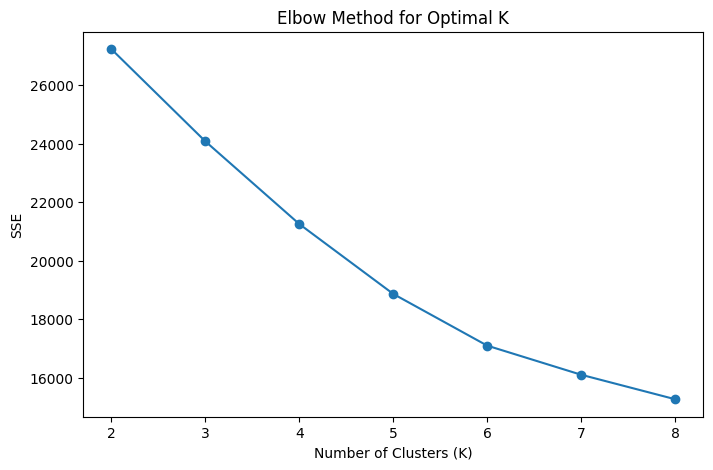

In [19]:
# 六、 用户分层
# 1. KMeans聚类（用户分群）用户聚类与精细化运营分析

cluster_features = ['Tenure','HourSpendOnApp',
                    'DiscountAmount','CouponUsed',
                    'NumberOfStreamerFollowed','SatisfactionScore']

x_cluster = df[cluster_features].copy()

assert x_cluster.isna().sum().sum() == 0

cluster_scaler = StandardScaler()
x_cluster_scaled = cluster_scaler.fit_transform(x_cluster)


# 选择最佳K值（轮廓系数法）
evaluation_records = []

for k in range(2, 9):
    model = KMeans(n_clusters=k,init='k-means++',n_init=20,random_state=42)
    labels = model.fit_predict(x_cluster_scaled)
    
    evaluation_records.append({"K": k,
                               "SSE": model.inertia_,
                               "Silhouette": silhouette_score(x_cluster_scaled,labels)})

evaluation_df = pd.DataFrame(evaluation_records)

print(f"Evaluation结果:\n{evaluation_df}")

# 绘制k值图

plt.figure(figsize=(8, 5))

plt.plot(evaluation_df["K"],evaluation_df["SSE"],marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE")
plt.title("Elbow Method for Optimal K")
plt.xticks(evaluation_df["K"])
plt.show()


In [20]:

evaluation_df['SilhouetteRank'] = (evaluation_df['Silhouette'].rank(ascending=False, method='dense').astype(int))

evaluation_df['Selected'] = np.where(evaluation_df['K'] == 4,
                                     'Yes - business interpretability',
                                     'No')

display(evaluation_df.round(4))

,K,SSE,Silhouette,SilhouetteRank,Selected
0,2,27230.8718,0.2316,1,No
1,3,24079.8616,0.1758,7,No
2,4,21252.6907,0.1898,5,Yes - business interpretability
3,5,18863.6810,0.1924,4,No
4,6,17095.7727,0.1933,2,No
5,7,16100.7018,0.1933,3,No
6,8,15263.8861,0.1839,6,No


K=2的轮廓系数最高，说明从纯统计分离角度看两组结构最清晰；考虑运营需要更细的行为画像，选择K=4。

K=4轮廓系数约为0.19，说明群体之间存在一定重叠，因此聚类结果定位为探索性用户画像，而不是绝对的用户类别。

In [21]:
# 拟合最终kmeans

best_k = 4

kmeans = KMeans(n_clusters=best_k,init='k-means++',n_init=20,random_state=42)
df['Cluster'] = kmeans.fit_predict(x_cluster_scaled)

# 分群统计与特征分析
cluster_analysis = df.groupby('Cluster').agg(Users=('CustomerID','count'),
                                             AvgTenure=('Tenure','mean'),
                                             AvgAppUsage=('HourSpendOnApp','mean'),
                                             AvgDiscount=('DiscountAmount','mean'),
                                             AvgCoupon=('CouponUsed','mean'),
                                             AvgStreamer=('NumberOfStreamerFollowed','mean'),
                                             AvgSatisfaction=('SatisfactionScore','mean'),
                                             ChurnRate=('Churn','mean'))

cluster_analysis['UserRate'] = (cluster_analysis['Users']/cluster_analysis['Users'].sum())
cluster_analysis['UserRate'] *= 100
cluster_analysis['ChurnRate'] *= 100


print(f"Cluster分析:\n{cluster_analysis}")

cluster_analysis.to_csv(PROCESSED_DATA_DIR/'Cluster_Analysis.csv', encoding='utf-8-sig')

Cluster分析:
         Users  AvgTenure  AvgAppUsage  AvgDiscount  AvgCoupon  AvgStreamer  AvgSatisfaction  ChurnRate   UserRate
Cluster                                                                                                           
0         2474   7.008892     2.570736   151.037187   1.027486     2.729184         2.985853  18.916734  43.943162
1          977  22.468782     2.823951   247.527124   1.388946     5.094166         3.121801   3.582395  17.353464
2         1709   8.540667     3.490930   169.088941   1.568169     5.955530         3.142774  21.357519  30.355240
3          470  12.470213     3.057447   198.476596   6.568085     3.868085         3.102128  17.021277   8.348135


In [22]:
#  根据cluster_analysis的数据对比，得出了以下4簇的业务映射关系

cluster_mapping = {0: '基础培育用户',
                   1: '长期忠诚用户',
                   2: '主播互动风险用户', 
                   3: '优惠敏感用户'}


df['Persona'] = df['Cluster'].map(cluster_mapping)

cluster_analysis['Persona'] = cluster_analysis.index.map(cluster_mapping)

print(f"带有业务角色的汇总表:\n{cluster_analysis[['Persona', 'Users', 'AvgTenure', 'AvgAppUsage', 'AvgDiscount', 'AvgCoupon', 'AvgStreamer', 'AvgSatisfaction', 'ChurnRate']]}")


带有业务角色的汇总表:
          Persona  Users  AvgTenure  AvgAppUsage  AvgDiscount  AvgCoupon  AvgStreamer  AvgSatisfaction  ChurnRate
Cluster                                                                                                          
0          基础培育用户   2474   7.008892     2.570736   151.037187   1.027486     2.729184         2.985853  18.916734
1          长期忠诚用户    977  22.468782     2.823951   247.527124   1.388946     5.094166         3.121801   3.582395
2        主播互动风险用户   1709   8.540667     3.490930   169.088941   1.568169     5.955530         3.142774  21.357519
3          优惠敏感用户    470  12.470213     3.057447   198.476596   6.568085     3.868085         3.102128  17.021277


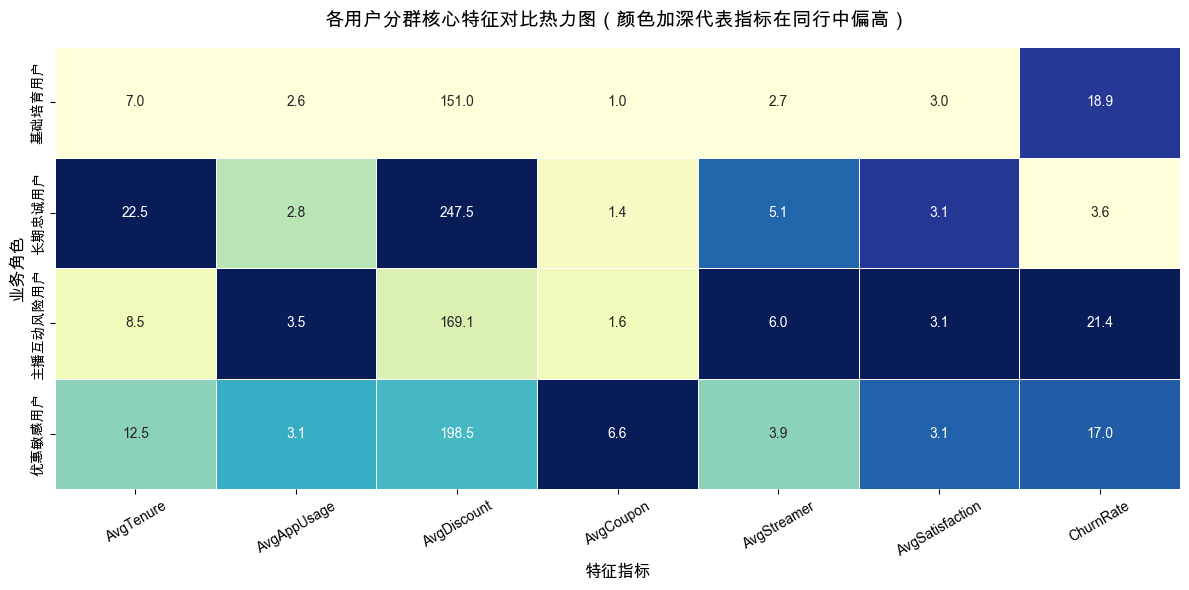

In [23]:
# 2. 绘制热力图（各用户分群核心特征对比）

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

features_to_show = ['AvgTenure', 'AvgAppUsage', 'AvgDiscount', 'AvgCoupon', 
                    'AvgStreamer', 'AvgSatisfaction', 'ChurnRate']

heatmap_data = cluster_analysis.set_index('Persona')[features_to_show]

heatmap_scaled = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

# 绘制热力图
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_scaled, 
            annot=heatmap_data,
            fmt=".1f", 
            cmap="YlGnBu", 
            cbar=False, 
            linewidths=0.5)

plt.title("各用户分群核心特征对比热力图（颜色加深代表指标在同行中偏高）", fontsize=14, pad=15)
plt.ylabel("业务角色", fontsize=12)
plt.xlabel("特征指标", fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


卡方检验显示投诉是关联较强且可干预的分类风险信号；
Welch t检验和Cohen’s d显示生命周期是区分流失与留存用户能力最强的连续变量；
逻辑回归显示二者在控制其他变量后仍保持显著关联。
因此，选择Tenure和Complain构建规则型风险等级。

In [24]:
# 3. 风险等级划分

risk_data = df.copy()

#  生命周期风险：生命周期越短，风险越高；相同生命周期得到相同排名

tenure_percentile = risk_data['Tenure'].rank(method='average',pct=True)

risk_data['TenureRisk'] = np.select([tenure_percentile <= 1/3,tenure_percentile <= 2/3],[3,2], default=1)  # 生命周期最短的约1/3

#  投诉风险
risk_data['ComplaintRisk'] = np.where(risk_data['Complain'] == 1,2,0)

#  风险评分 1~5分
risk_data['RiskScore'] = risk_data['TenureRisk'] + risk_data['ComplaintRisk']

risk_data['RiskLevel'] = pd.cut(risk_data['RiskScore'],
                              bins=[-np.inf, 2, 3, np.inf],
                              labels=['低风险', '中风险', '高风险'],
                              include_lowest=True)

df[['RiskScore', 'RiskLevel']] = (risk_data[['RiskScore', 'RiskLevel']])

risk_validation = (risk_data.groupby('RiskLevel', observed=True).agg(Users=('CustomerID', 'nunique'),
                                                                   ChurnUsers=('Churn', 'sum'),
                                                                   ActualChurnRate=('Churn', 'mean'),
                                                                   AvgRiskScore=('RiskScore', 'mean'),
                                                                   AvgTenure=('Tenure', 'mean'),
                                                                   AvgOrder=('OrderCount', 'mean'),
                                                                   ComplaintRate=('Complain', 'mean')).reset_index())

risk_validation['ActualChurnRate'] *= 100
risk_validation['ComplaintRate'] *= 100

risk_validation['UserRate'] = (risk_validation['Users']/ risk_validation['Users'].sum() * 100)

display(risk_validation.round(4))



,RiskLevel,Users,ChurnUsers,ActualChurnRate,AvgRiskScore,AvgTenure,AvgOrder,ComplaintRate,UserRate
0,低风险,2685,120,4.4693,1.5475,14.7199,3.2898,0.0000,47.6909
1,中风险,1841,364,19.7719,3.0000,7.6247,2.6573,27.1592,32.6998
2,高风险,1104,464,42.0290,4.5670,5.6060,2.6721,100.0000,19.6092


In [25]:
# 4. 策略计划
# 风险等级 × 用户价值 × 用户画像

#  生成运营优先级
priority_conditions = [
    # P1：高价值且高风险，优先人工干预
    ((df['RiskLevel'] == '高风险') & (df['RFG_Level'] == '高RFG综合表现')),

    # P2：其他高风险，或高价值中风险
    ((df['RiskLevel'] == '高风险') | ((df['RiskLevel'] == '中风险')& (df['RFG_Level'] == '高RFG综合表现'))),

    # P3：其他中风险
    df['RiskLevel'] == '中风险']

priority_choices = ['P1-重点挽留','P2-自动化召回','P3-持续培育']

df['ActionPriority'] = np.select(priority_conditions,
                                 priority_choices,
                                 default='P4-常规维护')

#  按用户画像匹配策略
persona_strategy = {'长期忠诚用户': {'Channel': '会员中心、站内信',
                                    'Action': '会员权益、新品优先购、积分激励',
                                    'PrimaryKPI': '30日复购率',
                                    'SecondaryKPI': '会员留存率'},
                    
                    '基础培育用户': {'Channel': 'APP首页、站内信',
                                    'Action': '新手任务、二单激励、核心品类推荐',
                                    'PrimaryKPI': '7日留存率',
                                    'SecondaryKPI': '二单转化率'},

                    '主播互动风险用户': {'Channel': '直播预约提醒、主播粉丝群',
                                         'Action': '主播回访直播、粉丝专享权益、同主播商品推荐',
                                         'PrimaryKPI': '直播回访率',
                                         'SecondaryKPI': '主播推荐复购率'},                   

                    '优惠敏感用户': {'Channel': '优惠券中心、APP推送',
                                    'Action': '门槛券、阶梯满减券，控制无门槛补贴',
                                    'PrimaryKPI': '优惠券增量核销率',
                                    'SecondaryKPI': '单笔增量订单补贴成本'}}

strategy_df = (pd.DataFrame(persona_strategy).T.rename_axis('Persona').reset_index())

df = df.merge(strategy_df,on='Persona',how='left')

#  根据风险等级调整触达强度
risk_action = pd.DataFrame({'RiskLevel': ['低风险', '中风险', '高风险'],
                            'ContactFrequency': ['常规触达','7天内触达1次','48小时内优先触达'],
                            'OfferIntensity': ['无额外补贴','低成本定向权益','视用户价值配置挽留权益']})

df = df.merge(risk_action,on='RiskLevel',how='left')

#  生成策略汇总表
strategy_plan = (df.groupby(['ActionPriority',
                             'RiskLevel',
                             'RFG_Level',
                             'Persona',
                             'Channel',
                             'Action',
                             'ContactFrequency',
                             'OfferIntensity',
                             'PrimaryKPI',
                             'SecondaryKPI'],observed=True,dropna=False).agg(Users=('CustomerID', 'nunique'),
                                                                             CurrentChurnUsers=('Churn', 'sum'),
                                                                             CurrentChurnRate=('Churn', 'mean'),
                                                                             AvgRiskScore=('RiskScore', 'mean'),
                                                                             AvgRFGScore=('RFG_Score', 'mean'),
                                                                             AvgOrder=('OrderCount', 'mean'),
                                                                             AvgDiscount=('DiscountAmount', 'mean'),
                                                                             ComplaintRate=('Complain', 'mean')).reset_index())

strategy_plan['UserRate'] = (strategy_plan['Users'] / strategy_plan['Users'].sum())

for col in ['CurrentChurnRate','ComplaintRate','UserRate']:
    strategy_plan[col] *= 100

priority_order = ['P1-重点挽留',
                  'P2-自动化召回',
                  'P3-持续培育',
                  'P4-常规维护']

strategy_plan['ActionPriority'] = pd.Categorical(strategy_plan['ActionPriority'],
                                                 categories=priority_order,ordered=True)

strategy_plan = strategy_plan.sort_values(['ActionPriority','CurrentChurnRate','Users'],ascending=[True, False, False])

strategy_plan.to_csv(PROCESSED_DATA_DIR/'Tableau_Strategy_plan.csv',index=False,encoding='utf-8-sig')

display(strategy_plan.round(2))


,ActionPriority,RiskLevel,RFG_Level,Persona,Channel,Action,ContactFrequency,OfferIntensity,PrimaryKPI,SecondaryKPI,Users,CurrentChurnUsers,CurrentChurnRate,AvgRiskScore,AvgRFGScore,AvgOrder,AvgDiscount,ComplaintRate,UserRate
0,P1-重点挽留,高风险,高RFG综合表现,主播互动风险用户,直播预约提醒、主播粉丝群,主播回访直播、粉丝专享权益、同主播商品推荐,48小时内优先触达,视用户价值配置挽留权益,直播回访率,主播推荐复购率,64,48,75.00,4.75,12.69,2.17,164.53,100.00,1.14
2,P1-重点挽留,高风险,高RFG综合表现,基础培育用户,APP首页、站内信,新手任务、二单激励、核心品类推荐,48小时内优先触达,视用户价值配置挽留权益,7日留存率,二单转化率,53,31,58.49,4.70,12.51,2.96,145.83,100.00,0.94
1,P1-重点挽留,高风险,高RFG综合表现,优惠敏感用户,优惠券中心、APP推送,门槛券、阶梯满减券，控制无门槛补贴,48小时内优先触达,视用户价值配置挽留权益,优惠券增量核销率,单笔增量订单补贴成本,16,2,12.50,4.56,12.31,7.75,177.56,100.00,0.28
3,P1-重点挽留,高风险,高RFG综合表现,长期忠诚用户,会员中心、站内信,会员权益、新品优先购、积分激励,48小时内优先触达,视用户价值配置挽留权益,30日复购率,会员留存率,2,0,0.00,4.00,12.00,7.00,264.00,100.00,0.04
9,P2-自动化召回,高风险,低RFG综合表现,优惠敏感用户,优惠券中心、APP推送,门槛券、阶梯满减券，控制无门槛补贴,48小时内优先触达,视用户价值配置挽留权益,优惠券增量核销率,单笔增量订单补贴成本,11,6,54.55,4.45,6.36,7.45,191.82,100.00,0.20
13,P2-自动化召回,高风险,中RFG综合表现,优惠敏感用户,优惠券中心、APP推送,门槛券、阶梯满减券，控制无门槛补贴,48小时内优先触达,视用户价值配置挽留权益,优惠券增量核销率,单笔增量订单补贴成本,56,27,48.21,4.54,9.70,7.54,181.18,100.00,0.99
12,P2-自动化召回,高风险,中RFG综合表现,主播互动风险用户,直播预约提醒、主播粉丝群,主播回访直播、粉丝专享权益、同主播商品推荐,48小时内优先触达,视用户价值配置挽留权益,直播回访率,主播推荐复购率,232,107,46.12,4.57,9.47,2.62,171.63,100.00,4.12
8,P2-自动化召回,高风险,低RFG综合表现,主播互动风险用户,直播预约提醒、主播粉丝群,主播回访直播、粉丝专享权益、同主播商品推荐,48小时内优先触达,视用户价值配置挽留权益,直播回访率,主播推荐复购率,70,28,40.00,4.50,6.29,2.14,172.33,100.00,1.24
14,P2-自动化召回,高风险,中RFG综合表现,基础培育用户,APP首页、站内信,新手任务、二单激励、核心品类推荐,48小时内优先触达,视用户价值配置挽留权益,7日留存率,二单转化率,373,147,39.41,4.60,9.40,2.34,151.61,100.00,6.63
4,P2-自动化召回,中风险,高RFG综合表现,主播互动风险用户,直播预约提醒、主播粉丝群,主播回访直播、粉丝专享权益、同主播商品推荐,7天内触达1次,低成本定向权益,直播回访率,主播推荐复购率,111,35,31.53,3.00,12.43,2.78,163.23,18.02,1.97


后续对P1和P2用户开展分层随机A/B测试，在相同RiskLevel、RFG_Level和Persona内随机分配实验组与对照组，比较30日增量留存率、增量复购率及单位挽留成本。

In [26]:
# 八、Tableau数据导出与质量检查
print(df.columns)


tableau_columns = ['CustomerID',
                   'Churn',

                   'Gender',
                   'AgeGroup',
                   'CityTier',
                   'MaritalStatus',
                   'PreferredLoginDevice',
                   'PreferedOrderCat',

                   'Tenure',
                   'WarehouseToHome',
                   'HourSpendOnApp',
                   'OrderCount',
                   'OrderAmountHikeFromlastYear',
                   'DaySinceLastOrder',
                   'NumberOfStreamerFollowed',
                   'SatisfactionScore',
                   'Complain',
                   'CouponUsed',
                   'DiscountAmount',

                   'CouponFlag',
                   'TenureGroup',
                   'AppUsageLevel',
                   'StreamerGroup',
                   'LastOrderGroup',

                   'R_score',
                   'F_score',
                   'G_score',
                   'RFG_Score',
                   'RFG_Level',

                   'Cluster',
                   'Persona',

                   'RiskScore',
                   'RiskLevel',

                   'ActionPriority',
                   'ContactFrequency',
                   'Action',
                   'Channel',
                   'PrimaryKPI',
                   'SecondaryKPI',
                   'OfferIntensity']

missing_columns = [col for col in tableau_columns
                   if col not in df.columns]

assert not missing_columns, (f"缺少Tableau字段：{missing_columns}")

print(df.head(10))

tableau_data = df[tableau_columns].copy()

# 分类字段转为普通字符串
category_columns = tableau_data.select_dtypes(include=['category']).columns

tableau_data[category_columns] = (tableau_data[category_columns].astype('string'))

# 最终质量检查
assert len(tableau_data) == 5630
assert tableau_data['CustomerID'].nunique() == 5630
assert tableau_data['CustomerID'].duplicated().sum() == 0
assert tableau_data['RiskLevel'].isna().sum() == 0
assert tableau_data['RFG_Level'].isna().sum() == 0
assert tableau_data['Persona'].isna().sum() == 0
assert tableau_data['ActionPriority'].isna().sum() == 0

tableau_quality = pd.DataFrame({
    'Metric': ['Rows',
               'Unique customers',
               'Duplicate customers',
               'Missing values',
               'Churn rate',
               'Risk coverage',
               'RFG coverage',
               'Persona coverage'],

    'Value': [len(tableau_data),
                  tableau_data['CustomerID'].nunique(),
                  tableau_data['CustomerID'].duplicated().sum(),
                  tableau_data.isna().sum().sum(),
                  tableau_data['Churn'].mean(),
                  tableau_data['RiskLevel'].notna().mean(),
                  tableau_data['RFG_Level'].notna().mean(),
                  tableau_data['Persona'].notna().mean()]})

display(tableau_quality)

tableau_data.to_csv(PROCESSED_DATA_DIR/'Tableau_LiveCommerce_UserDetail.csv',index=False,encoding='utf-8-sig')

print("Tableau数据导出完成。")

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'MaritalStatus', 'AgeGroup', 'Gender', 'HourSpendOnApp', 'OrderCount', 'OrderAmountHikeFromlastYear',
       'DaySinceLastOrder', 'PreferedOrderCat', 'NumberOfStreamerFollowed', 'SatisfactionScore', 'Complain', 'CouponUsed', 'DiscountAmount', 'CouponFlag', 'TenureGroup', 'AppUsageLevel',
       'StreamerGroup', 'LastOrderGroup', 'R_score', 'F_score', 'G_score', 'RFG_Score', 'RFG_Level', 'Cluster', 'Persona', 'RiskScore', 'RiskLevel', 'ActionPriority', 'Channel', 'Action',
       'PrimaryKPI', 'SecondaryKPI', 'ContactFrequency', 'OfferIntensity'],
      dtype='str')
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome MaritalStatus  AgeGroup  Gender  HourSpendOnApp  OrderCount  OrderAmountHikeFromlastYear  DaySinceLastOrder  \
0       50001      1     4.0         Mobile Phone         3              6.0        Single         3  Female             3.0           1         

,Metric,Value
0,Rows,5630.000000
1,Unique customers,5630.000000
2,Duplicate customers,0.000000
3,Missing values,0.000000
4,Churn rate,0.168384
5,Risk coverage,1.000000
6,RFG coverage,1.000000
7,Persona coverage,1.000000


Tableau数据导出完成。
